2000-2026年全球商品价格分析  
黄金、白银、原油、天然气、铜和铂的每日价格  
数据来源：https://www.kaggle.com/datasets/ibrahimqasimi/global-commodity-prices-2000-2026

#### 前言

这个数据集包含了2000年至2026年全球主要商品的每日价格数据，包括黄金、白银、原油、天然气、铜和铂。这些数据可以帮助我们分析全球商品价格的趋势和波动，了解不同商品之间的关系，以及预测未来的价格走势。指标包括日期、商品名称、价格等。  
以下应用了时间序列分析、周期识别、相关性分析和预测模型等方法来深入分析这些数据。

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [33]:
data = pd.read_csv('Global_Commodity_Prices_2000_2026.csv', parse_dates=['Date'])

In [34]:
data.head()

,Date,Open,High,Low,Close,Volume,Ticker,Commodity
0,2000-08-30,273.899994,273.899994,273.899994,273.899994,0,GC=F,Gold
1,2000-08-31,274.799988,278.299988,274.799988,278.299988,0,GC=F,Gold
2,2000-09-01,277.000000,277.000000,277.000000,277.000000,0,GC=F,Gold
3,2000-09-05,275.799988,275.799988,275.799988,275.799988,2,GC=F,Gold
4,2000-09-06,274.200012,274.200012,274.200012,274.200012,0,GC=F,Gold


In [35]:
data.tail()

,Date,Open,High,Low,Close,Volume,Ticker,Commodity
37997,2026-03-20,1970.599976,1970.599976,1970.599976,1970.599976,0,PL=F,Platinum
37998,2026-03-23,1860.300049,1860.300049,1860.300049,1860.300049,2,PL=F,Platinum
37999,2026-03-24,1892.000000,1892.000000,1892.000000,1892.000000,18,PL=F,Platinum
38000,2026-03-25,1925.199951,1925.199951,1925.199951,1925.199951,18,PL=F,Platinum
38001,2026-03-26,NaN,NaN,NaN,NaN,290,PL=F,Platinum


In [36]:
data.info() 

<class 'pandas.DataFrame'>
RangeIndex: 38002 entries, 0 to 38001
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       38002 non-null  datetime64[us]
 1   Open       37996 non-null  float64       
 2   High       37996 non-null  float64       
 3   Low        37996 non-null  float64       
 4   Close      37996 non-null  float64       
 5   Volume     38002 non-null  int64         
 6   Ticker     38002 non-null  str           
 7   Commodity  38002 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(2)
memory usage: 2.3 MB


In [37]:
data['Commodity'].unique()

<StringArray>
['Gold', 'Silver', 'Crude Oil WTI', 'Natural Gas', 'Copper', 'Platinum']
Length: 6, dtype: str

In [38]:
# 清洗数据
data = data.dropna(subset=['Close']) # 只删除 'Close' 列中缺失值的行
data['Close'] = pd.to_numeric(data['Close'], errors='coerce') 
# 将 'Close' 列转换为数值类型，无法转换的值将被设置为 NaN
data = data.dropna(subset=['Close']) # 再次删除 'Close' 列中缺失值的行

In [39]:
data.iloc[:, [1, 2, 3, 4]].describe()

,Open,High,Low,Close
count,37996.000000,37996.000000,37996.000000,37996.000000
mean,399.187597,401.075556,397.258523,399.217656
std,656.025483,659.250068,652.622823,655.992127
min,-14.000000,0.609500,-40.320000,-37.630001
25%,4.212375,4.261000,4.154750,4.214750
50%,29.549999,29.952500,29.160000,29.549500
75%,791.000015,793.725006,788.024994,790.500000
max,5415.700195,5586.200195,5301.600098,5318.399902


#### 趋势分析

In [40]:
# 拆分
prices_Gold = data.loc[data['Commodity'] == 'Gold', :]
prices_Silver = data.loc[data['Commodity'] == 'Silver', :] 
prices_Copper = data.loc[data['Commodity'] == 'Copper', :]
prices_Oil = data.loc[data['Commodity'] == 'Crude Oil WTI', :]
prices_Natural_Gas = data.loc[data['Commodity'] == 'Natural Gas', :]
prices_Platinum = data.loc[data['Commodity'] == 'Platinum', :]

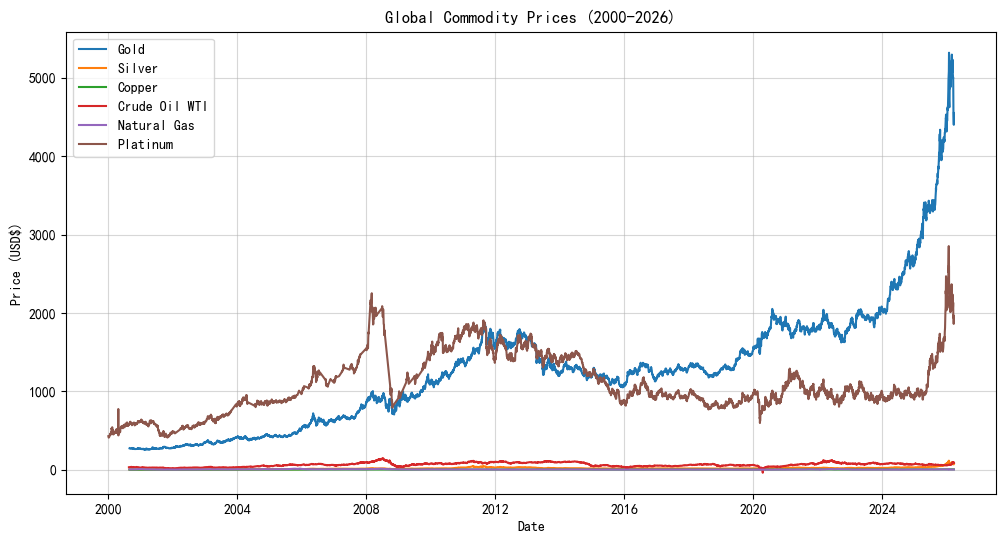

In [41]:
# 绘制价格趋势图
plt.figure(figsize=(12, 6))
plt.plot(prices_Gold['Date'], prices_Gold['Close'], label='Gold')
plt.plot(prices_Silver['Date'], prices_Silver['Close'], label='Silver')
plt.plot(prices_Copper['Date'], prices_Copper['Close'], label='Copper')
plt.plot(prices_Oil['Date'], prices_Oil['Close'], label='Crude Oil WTI')
plt.plot(prices_Natural_Gas['Date'], prices_Natural_Gas['Close'], label='Natural Gas')
plt.plot(prices_Platinum['Date'], prices_Platinum['Close'], label='Platinum')
plt.title('Global Commodity Prices (2000-2026)')
plt.xlabel('Date')
plt.ylabel('Price (USD$)')
plt.legend() # 显示图例
plt.grid(alpha=0.5) # 显示网格线
# # 修改绘图后端为plotly
# pd.options.plotting.backend = "plotly"   
plt.show()

In [42]:
# # 把价格趋势图用 plotly 再画一遍
# %pip install kaleido
# import plotly.express as px
# import plotly.io as pio

# # 设置为静态图像模式，避免 nbformat 兼容性问题
# pio.renderers.default = 'png'

# fig = px.line(data, x='Date', y='Close', color='Commodity', 
#               title='Global Commodity Prices (2000-2026)')
# fig.update_layout(xaxis_title='Date', yaxis_title='Price (USD$)')
# fig.show()
 

#### 周期性分析

思路：  
季节性强度 = 季节性方差占总方差的比例，计算并排序。  
使用时间序列分解方法（STL分解）将价格数据分解为趋势、季节性和残差部分，识别价格的周期性模式。   
找到季节性最强的月份，列出两种季节性强度。  
最后试着用Fourier变换将时间序列从“时间维度”转换为“频率维度”。但面对非平稳信号效果打折扣，意义不大。

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.fft import fft, fftfreq

# 提取时间特征
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Quarter'] = data['Date'].dt.quarter
data['DayOfWeek'] = data['Date'].dt.dayofweek

commodities = ['Gold', 'Silver', 'Copper', 'Crude Oil WTI', 'Natural Gas', 'Platinum']


##### 1. 月度聚合分析

In [44]:
print("1. 月度聚合分析", "\n")

monthly_avg = (data.groupby(['Commodity', 'Year', 'Month'])['Close']
               .mean().reset_index()) # reset_index重置索引
# print(monthly_avg.head(), "\n")
monthly_avg['Date'] = pd.to_datetime(monthly_avg['Year'].astype(str) + '-'
                                    + monthly_avg['Month'].astype(str) + '-01')
# 把年月转换为日期格式，方便后续分析和绘图

# 季节性强度
seasonal_strength = {}
for commodity in commodities:
    commodity_data = monthly_avg[monthly_avg['Commodity'] == commodity]
    yearly_avg = commodity_data.groupby('Year')['Close'].mean()
    seasonal_var = commodity_data.groupby('Month')['Close'].var().mean()
    total_var = commodity_data['Close'].var()
    seasonal_strength[commodity] = seasonal_var / total_var
    # 计算季节性强度，季节性方差占总方差的比例

print("\n季节性强度（越高表示季节性越明显）：")
for commodity, strength in sorted(seasonal_strength.items(),
                                   key = lambda x: x[1], reverse=True):
    # 按值大小降序排列
    print(f"  {commodity}: {strength:.3f}")

1. 月度聚合分析 


季节性强度（越高表示季节性越明显）：
  Copper: 1.034
  Gold: 1.031
  Crude Oil WTI: 1.030
  Natural Gas: 1.028
  Silver: 1.025
  Platinum: 1.025


#####  2. 季节性分解

In [45]:
print("2. 季节性分解")

for commodity in commodities:
    commodity_data = data[data['Commodity'] == commodity].copy()
    monthly_data = (commodity_data.set_index('Date')['Close']
                    .resample('ME').mean().dropna()) # M更新为ME, dropna 必须
    # 同上
    
    decomposition = seasonal_decompose(monthly_data, model='additive', period=12)
    # 使用STL分解方法（处理非平稳时间序列）将价格数据分解为趋势、
    # 季节性和残差部分，识别价格的周期性模式。
    # model='additive' 表示使用加法模型，period=12 表示季节性周期为12个月（即一年）。
    
    seasonal_mean = decomposition.seasonal.mean()
    seasonal_std = decomposition.seasonal.std()
    
    print(f"\n{commodity}:")
    print(f"  季节性成分均值: {seasonal_mean:.2f}")
    print(f"  季节性成分标准差: {seasonal_std:.2f}")
    
    # 找出季节性最强的月份
    seasonal_by_month = decomposition.seasonal.groupby(decomposition.seasonal.index.month).mean()
    max_month = seasonal_by_month.idxmax() # idxmax() 返回最大值所在的索引，即月份
    min_month = seasonal_by_month.idxmin()
    print(f"  季节性高峰月份: {max_month} (偏移 +{seasonal_by_month[max_month]:.2f})")
    print(f"  季节性低谷月份: {min_month} (偏移 {seasonal_by_month[min_month]:.2f})")
    # 偏移指的是该月份的季节性成分值，正值表示高于平均水平，负值表示低于平均水平。

    # 季节性强度（极差法）
    seasonal_strength = seasonal_by_month.max() - seasonal_by_month.min()
    # 即季节性成分的最大值与最小值之差，数值越大表示季节性越强。
    print(f"  季节性强度: {seasonal_strength:.2f}")
    
    # 季节性强度（基于方差）
    var_seasonal = decomposition.seasonal.var()
    var_resid = decomposition.resid.dropna().var()  # dropna处理NaN
    if var_seasonal + var_resid > 0:
        seasonal_strength_variance = var_seasonal / (var_seasonal + var_resid)
    else:
        seasonal_strength_variance = 0
    print(f"  季节性强度 (基于方差): {seasonal_strength_variance:.3f}")


2. 季节性分解

Gold:
  季节性成分均值: -0.06
  季节性成分标准差: 10.82
  季节性高峰月份: 4 (偏移 +20.91)
  季节性低谷月份: 12 (偏移 -18.09)
  季节性强度: 39.01
  季节性强度 (基于方差): 0.041

Silver:
  季节性成分均值: -0.00
  季节性成分标准差: 0.28
  季节性高峰月份: 4 (偏移 +0.58)
  季节性低谷月份: 7 (偏移 -0.27)
  季节性强度: 0.85
  季节性强度 (基于方差): 0.027

Copper:
  季节性成分均值: -0.00
  季节性成分标准差: 0.06
  季节性高峰月份: 4 (偏移 +0.10)
  季节性低谷月份: 11 (偏移 -0.09)
  季节性强度: 0.19
  季节性强度 (基于方差): 0.063

Crude Oil WTI:
  季节性成分均值: -0.03
  季节性成分标准差: 2.19
  季节性高峰月份: 7 (偏移 +3.19)
  季节性低谷月份: 12 (偏移 -4.06)
  季节性强度: 7.26
  季节性强度 (基于方差): 0.092

Natural Gas:
  季节性成分均值: 0.00
  季节性成分标准差: 0.19
  季节性高峰月份: 11 (偏移 +0.33)
  季节性低谷月份: 3 (偏移 -0.23)
  季节性强度: 0.56
  季节性强度 (基于方差): 0.058

Platinum:
  季节性成分均值: -0.02
  季节性成分标准差: 7.68
  季节性高峰月份: 11 (偏移 +8.92)
  季节性低谷月份: 6 (偏移 -8.37)
  季节性强度: 17.28
  季节性强度 (基于方差): 0.006


##### 3. 周期识别


3. 主要周期识别（傅里叶变换）


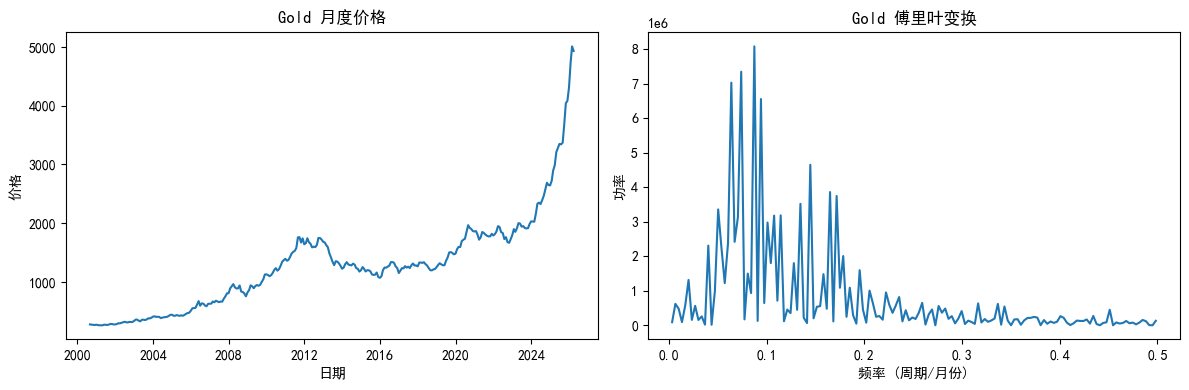


Gold:
  周期 1: 11.4 个月 (功率: 8.08e+06)
  周期 2: 13.5 个月 (功率: 7.35e+06)
  周期 3: 15.6 个月 (功率: 7.03e+06)


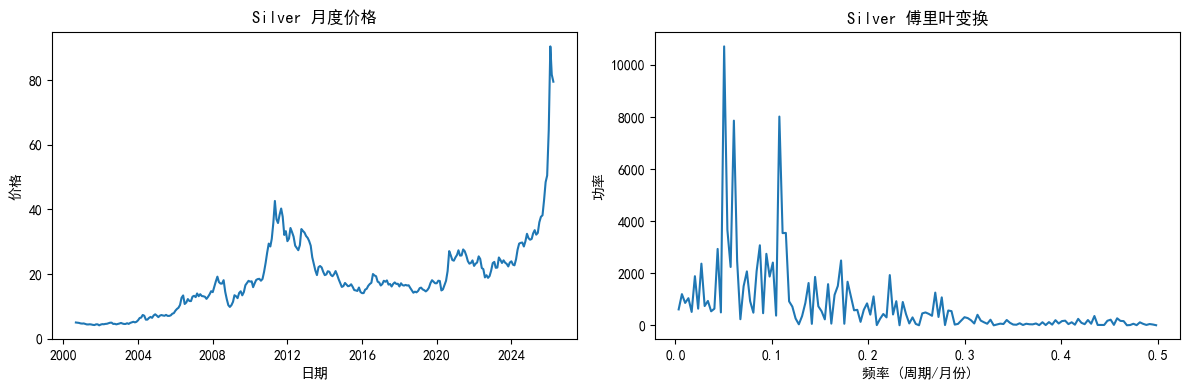


Silver:
  周期 1: 19.8 个月 (功率: 1.07e+04)
  周期 2: 9.3 个月 (功率: 8.01e+03)
  周期 3: 16.5 个月 (功率: 7.86e+03)


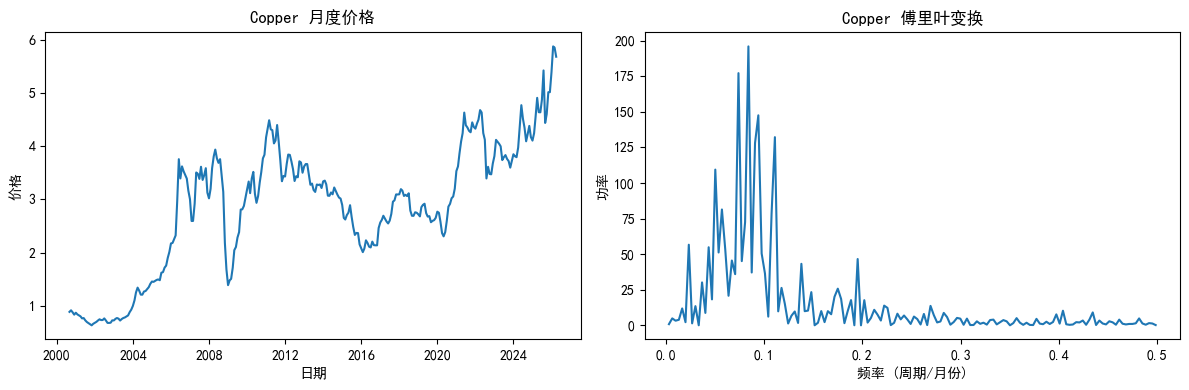


Copper:
  周期 1: 11.9 个月 (功率: 1.96e+02)
  周期 2: 13.5 个月 (功率: 1.77e+02)
  周期 3: 10.6 个月 (功率: 1.48e+02)


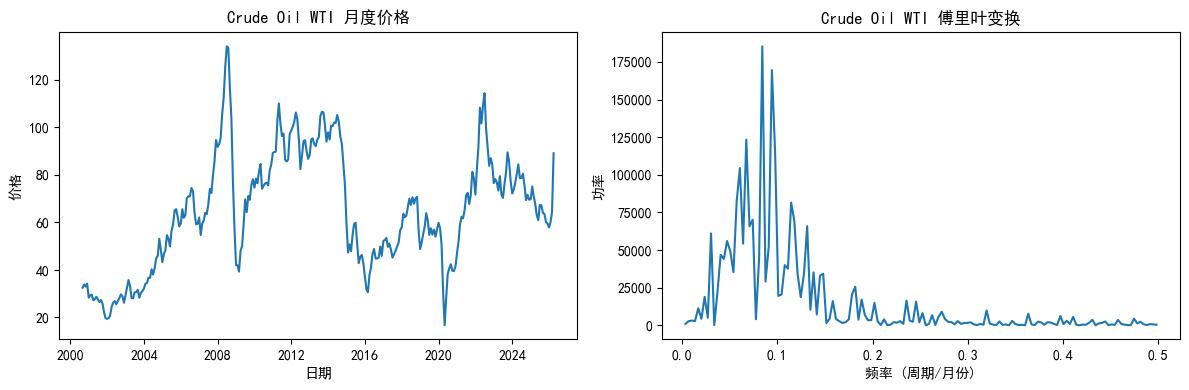


Crude Oil WTI:
  周期 1: 11.9 个月 (功率: 1.85e+05)
  周期 2: 10.6 个月 (功率: 1.70e+05)
  周期 3: 14.8 个月 (功率: 1.23e+05)


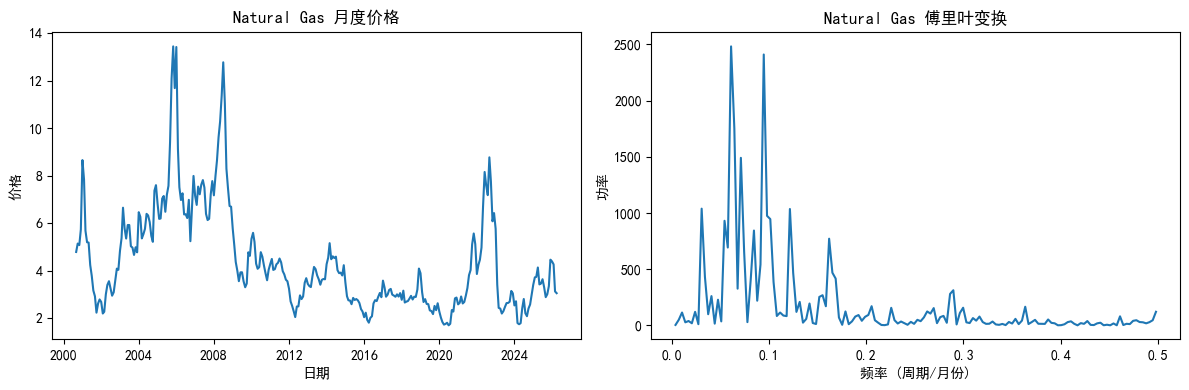


Natural Gas:
  周期 1: 16.5 个月 (功率: 2.48e+03)
  周期 2: 10.6 个月 (功率: 2.41e+03)
  周期 3: 15.6 个月 (功率: 1.75e+03)


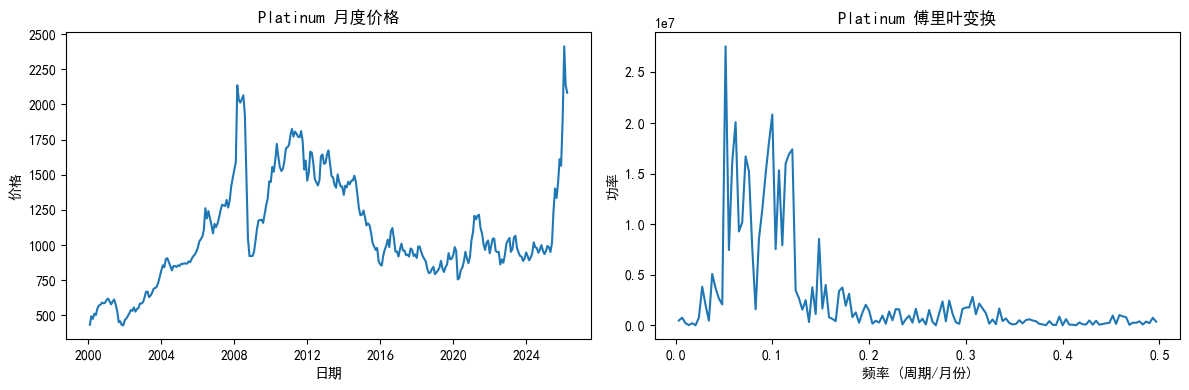


Platinum:
  周期 1: 19.3 个月 (功率: 2.76e+07)
  周期 2: 10.0 个月 (功率: 2.08e+07)
  周期 3: 16.1 个月 (功率: 2.01e+07)


In [46]:

print("\n3. 主要周期识别（傅里叶变换）")

for commodity in commodities:
    commodity_data = data[data['Commodity'] == commodity].copy()
    monthly_data = commodity_data.set_index('Date')['Close'].resample('ME').mean().dropna()
    # M更新为ME
    
    # 去趋势，滚动
    detrended = monthly_data - monthly_data.rolling(12, center=True).mean()
    detrended = detrended.dropna()
    
    # 傅里叶变换
    n = len(detrended) # len() 函数返回对象（字符串、列表、元组等）长度或项目个数
    fft_result = fft(detrended.values)
    freq = fftfreq(n, d=1) 
    # d=1 表示每个月一个数据点，频率单位是周期/月份.生成 FFT 输出结果对应的频率轴。
    
    positive_freq_idx = freq > 0
    freq_positive = freq[positive_freq_idx]
    power = np.abs(fft_result[positive_freq_idx]) ** 2

    # 画傅里叶变换的结果图，显示频率和功率的关系
    # 功率表示每个频率成分的强度，频率越高表示周期越短，频率越低表示周期越长
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(monthly_data.index, monthly_data.values)
    plt.title(f"{commodity} 月度价格")
    plt.xlabel("日期")
    plt.ylabel("价格")

    plt.subplot(1, 2, 2)
    plt.plot(freq_positive, power)
    plt.title(f"{commodity} 傅里叶变换")
    plt.xlabel("频率 (周期/月份)")
    plt.ylabel("功率")
    plt.tight_layout()
    plt.show()

    # 找出前3个主要周期
    peaks = np.argsort(power)[-3:][::-1]
    # np.argsort(power) 返回 power 数组中元素从小到大的索引，
    # [-3:] 取出最后三个索引（即功率最大的三个频率），[::-1] 将它们反转为从大到小的顺序。
    
    print(f"\n{commodity}:")
    for rank, peak in enumerate(peaks, 1):
        period = 1/freq_positive[peak]
        if 2 < period < 36:
            print(f"  周期 {rank}: {period:.1f} 个月 (功率: {power[peak]:.2e})")


In [47]:
from pyecharts import options as opts
from pyecharts.charts import Map, Bar, Line
from pyecharts.components import Table
from pyecharts.options import ComponentTitleOpts
table = Table()
headers = ['商品', '周期类型', '季节性强度', '高峰期', '低谷期', '解释']
rows = [
    ['Gold', '年周期', 0.041, '4月', '12月', '受美元、通胀预期影响，春季上涨、年末下跌'],
    ['Silver', '年周期', 0.027, '4月', '7月', '跟随黄金走势，工业需求影响有限'],
    ['Copper', '年周期', 0.063, '4月', '11月', '建筑旺季（春季）需求推高价格'],
    ['Crude Oil WTI', '年周期', 0.092, '7月', '12月', '夏季驾车高峰推高需求，年末回落'],
    ['Natural Gas', '年周期', 0.058, '11月', '3月', '冬季取暖需求导致冬季高峰'],
    ['Platinum', '年周期', 0.006, '11月', '6月', '汽车催化剂需求，季节性最弱']
]
table.add(headers, rows) # 表格的表头和数据行添加到表格组件中。
table.set_global_opts(title_opts = ComponentTitleOpts(title = "主要周期类型及解释（修正版）"))
table.render_notebook()


商品,周期类型,季节性强度,高峰期,低谷期,解释
Gold,年周期,0.041,4月,12月,受美元、通胀预期影响，春季上涨、年末下跌
Silver,年周期,0.027,4月,7月,跟随黄金走势，工业需求影响有限
Copper,年周期,0.063,4月,11月,建筑旺季（春季）需求推高价格
Crude Oil WTI,年周期,0.092,7月,12月,夏季驾车高峰推高需求，年末回落
Natural Gas,年周期,0.058,11月,3月,冬季取暖需求导致冬季高峰
Platinum,年周期,0.006,11月,6月,汽车催化剂需求，季节性最弱


参考意义不大。

#### 相关性分析

In [48]:
import seaborn as sns
from scipy import stats

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False # 确保负号正常显示

# 提取时间特征
data['YearMonth'] = data['Date'].dt.to_period('M')

# 创建月度数据透视表
monthly_pivot = data.pivot_table(
    values='Close', 
    index='YearMonth', 
    columns='Commodity', 
    aggfunc='mean'
).dropna()

print("1. 相关性矩阵")

# 计算相关系数矩阵
correlation_matrix = monthly_pivot.corr()
print("\n相关系数矩阵：")
print(correlation_matrix.round(3)) # 四舍五入到小数点后三位

# 找出相关性最强的商品对
print("\n\n相关性强度排名（按相关系数绝对值）：")
print("-" * 60)

# 获取上三角矩阵的索引
corr_pairs = []
for i in range(6):
    for j in range(i+1, 6): # 避免重复自相关。[i , j]共C62=15对（组合数）
        commodity1 = correlation_matrix.columns[i]
        commodity2 = correlation_matrix.columns[j]
        corr_value = correlation_matrix.iloc[i, j]
        corr_pairs.append((commodity1, commodity2, corr_value))

# 按相关系数绝对值排序
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True) # 按相关系数绝对值降序排序

# 显示前10个最强的相关性
print("\n最相关的商品对 TOP 10：")
for rank, (c1, c2, corr) in enumerate(corr_pairs[:10], 1):
    strength = "强正相关" if corr > 0.7 else "中等正相关" if corr > 0.4 else "弱正相关" if corr > 0 else "负相关"
    print(f"{rank:2d}. {c1:15s} <-> {c2:15s}: {corr:+.3f} ({strength})")
    # 2d 表示排名占两位，15s 表示商品名称占15个字符宽度

# 统计相关性强度分布
print("\n\n相关性强度分布：")
strong_pos = sum(1 for _, _, c in corr_pairs if c > 0.7)
# 从 corr_pairs 中解包每个三元组，只取相关系数值 c
medium_pos = sum(1 for _, _, c in corr_pairs if 0.4 < c <= 0.7)
weak_pos = sum(1 for _, _, c in corr_pairs if 0 < c <= 0.4)
negative = sum(1 for _, _, c in corr_pairs if c < 0) #负相关

print(f"  强正相关 (>0.7):    {strong_pos:2d} 对")
print(f"  中等正相关 (0.4-0.7): {medium_pos:2d} 对")
print(f"  弱正相关 (0-0.4):    {weak_pos:2d} 对")
print(f"  负相关 (<0):         {negative:2d} 对")


1. 相关性矩阵

相关系数矩阵：
Commodity      Copper  Crude Oil WTI   Gold  Natural Gas  Platinum  Silver
Commodity                                                                 
Copper          1.000          0.726  0.821       -0.148     0.670   0.831
Crude Oil WTI   0.726          1.000  0.378        0.171     0.741   0.504
Gold            0.821          0.378  1.000       -0.382     0.438   0.912
Natural Gas    -0.148          0.171 -0.382        1.000     0.107  -0.290
Platinum        0.670          0.741  0.438        0.107     1.000   0.680
Silver          0.831          0.504  0.912       -0.290     0.680   1.000


相关性强度排名（按相关系数绝对值）：
------------------------------------------------------------

最相关的商品对 TOP 10：
 1. Gold            <-> Silver         : +0.912 (强正相关)
 2. Copper          <-> Silver         : +0.831 (强正相关)
 3. Copper          <-> Gold           : +0.821 (强正相关)
 4. Crude Oil WTI   <-> Platinum       : +0.741 (强正相关)
 5. Copper          <-> Crude Oil WTI  : +0.726 (强正相关)
 6. Plat

##### 2. 相关性可视化

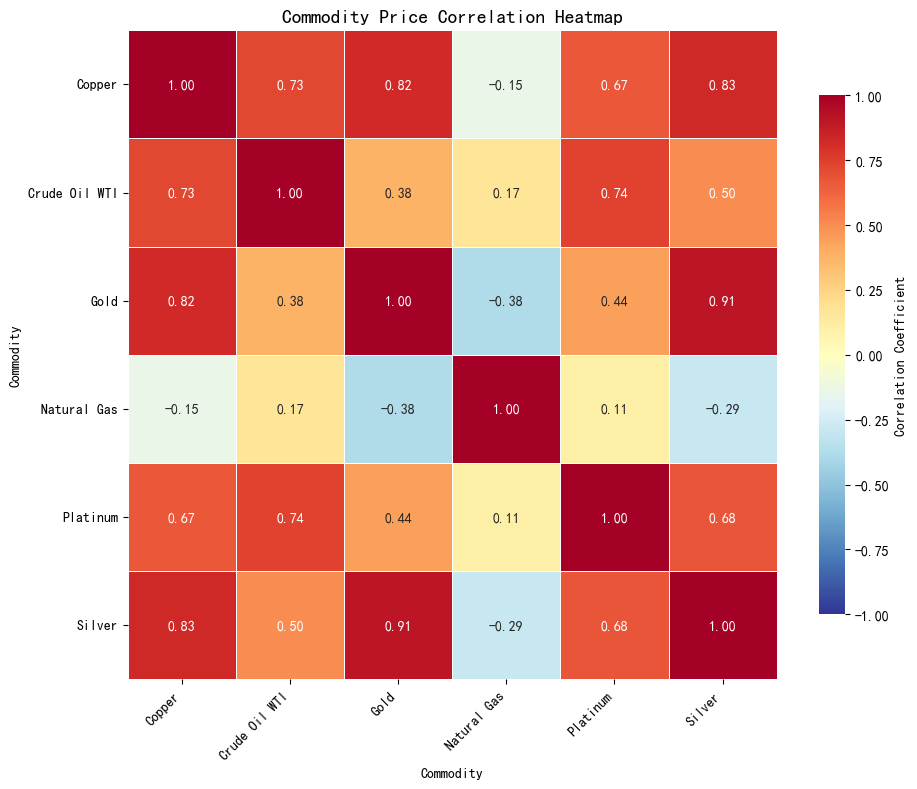


热力图解释：
  - 红色区域：正相关（价格同向变动）
  - 蓝色区域：负相关（价格反向变动）
  - 白色区域：接近零相关性


In [49]:
# 绘制相关性热力图
fig, ax = plt.subplots(figsize=(10, 8))

# 创建热力图
mask = np.zeros_like(correlation_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # 只显示下三角

sns.heatmap(
    correlation_matrix, 
    annot = True,  # 单元格显示相关系数数值
    fmt = '.2f',  # 格式化为小数点后两位
    cmap = 'RdYlBu_r',  # 红黄蓝配色，正相关为红色
    center = 0,
    square = True,
    linewidths = 0.5,
    cbar_kws = {"shrink": 0.8, "label": "Correlation Coefficient"},
    ax = ax,
    vmin = -1, vmax = 1
)

ax.set_title('Commodity Price Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right') # 旋转 x 轴标签以防止重叠
plt.yticks(rotation=0) 
plt.tight_layout() # 调整布局以防止标签重叠
plt.show()

print("\n热力图解释：")
print("  - 红色区域：正相关（价格同向变动）")
print("  - 蓝色区域：负相关（价格反向变动）")
print("  - 白色区域：接近零相关性")


##### 3. 散点图矩阵

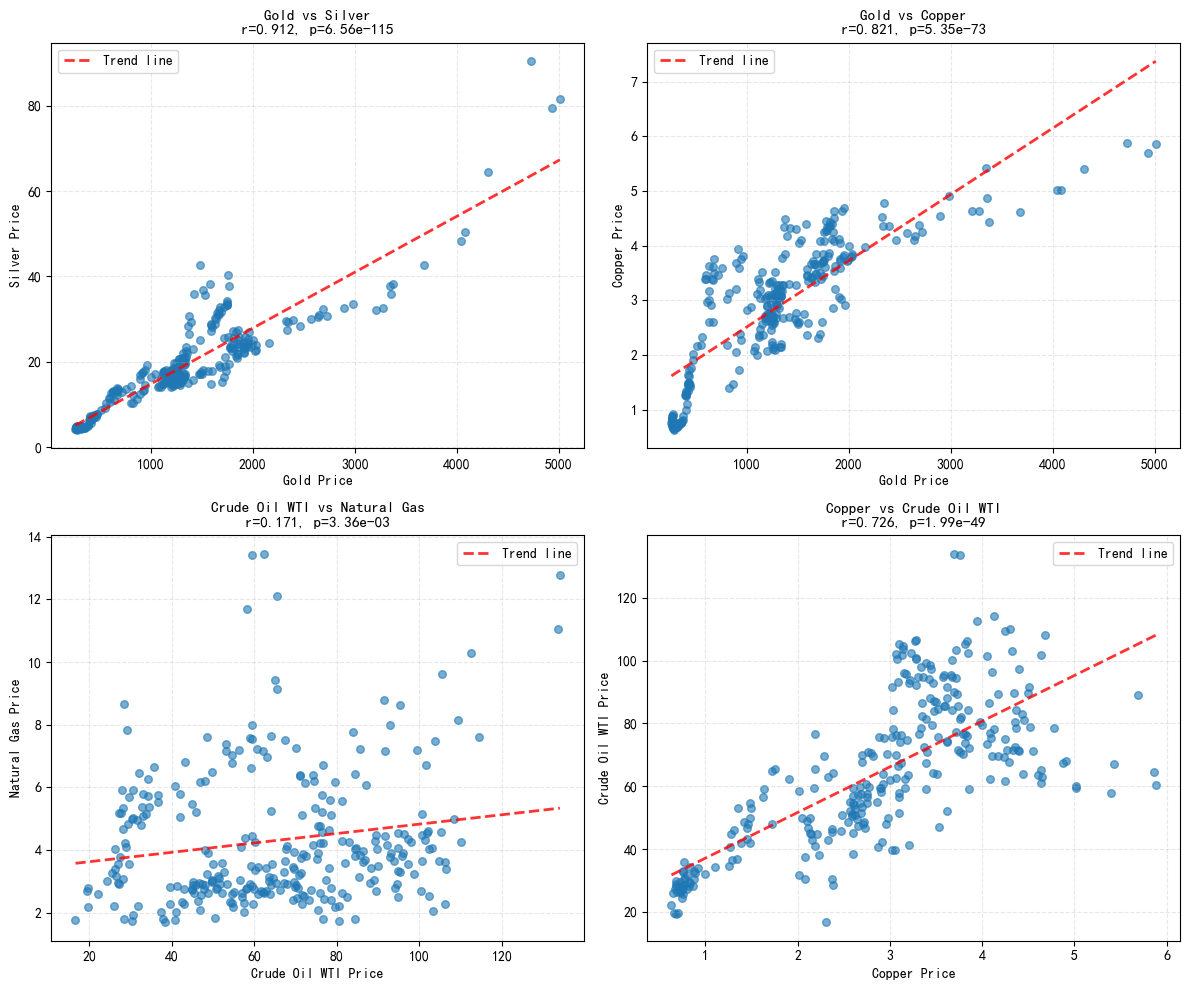


散点图解释：
  - 数据点分布越接近对角线，相关性越强
  - 红色虚线为趋势线，斜率表示相关方向
  - p值 < 0.05 表示相关性显著


In [50]:
# 绘制散点图矩阵（只选择部分商品）
selected_commodities = ['Gold', 'Silver', 'Copper', 'Crude Oil WTI']
subset_data = monthly_pivot[selected_commodities].copy()

# 创建配对散点图
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel() # 展平

# 以下相当于axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]
# index -> idx
for idx, (c1, c2) in enumerate([('Gold', 'Silver'), 
                                 ('Gold', 'Copper'),
                                 ('Crude Oil WTI', 'Natural Gas'),
                                 ('Copper', 'Crude Oil WTI')]):
    ax = axes[idx]
    
    # 散点图
    ax.scatter(monthly_pivot[c1], monthly_pivot[c2], alpha=0.6, s=30)
    # s -> size
    
    # 添加趋势线
    z = np.polyfit(monthly_pivot[c1], monthly_pivot[c2], 1)
    p = np.poly1d(z) # 生成一个多项式函数对象，表示拟合的线性关系
    x_line = np.linspace(monthly_pivot[c1].min(), monthly_pivot[c1].max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, label='Trend line')
    
    # 计算相关系数和p值
    corr, p_value = stats.pearsonr(monthly_pivot[c1], monthly_pivot[c2])
    # stats.pearsonr() 函数计算两个变量之间的 Pearson 相关系数和对应的 p 值，
    # 评估相关性的强度和统计显著性。
    
    ax.set_xlabel(f'{c1} Price', fontsize=10)
    ax.set_ylabel(f'{c2} Price', fontsize=10)
    ax.set_title(f'{c1} vs {c2}\nr={corr:.3f}, p={p_value:.2e}', fontsize=11)
    ax.legend()
    ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n散点图解释：")
print("  - 数据点分布越接近对角线，相关性越强")
print("  - 红色虚线为趋势线，斜率表示相关方向")
print("  - p值 < 0.05 表示相关性显著")


##### 4. 分组相关性分析

主要把数据分成三组，2000-2007年、2008-2014年和2015-2026年，计算每组的相关性矩阵并进行对比分析。

In [51]:
# 按时期分组分析相关性
# 定义时期
def get_period(year):
    if year < 2008:
        return '2000-2007'
    elif year < 2015:
        return '2008-2014'
    else:
        return '2015-2026'

data['Period'] = data['Year'].apply(get_period)
# 对'Year'列应用get_period函数

# 计算不同时期的相关性
print("不同时期的相关性对比")

for period in ['2000-2007', '2008-2014', '2015-2026']:
    period_data = data[data['Period'] == period]
    period_pivot = period_data.pivot_table(
        values='Close', 
        index='YearMonth', 
        columns='Commodity', 
        aggfunc='mean'
    ).dropna()
    
    if len(period_pivot) > 10:  # 至少需要10个月的数据
        period_corr = period_pivot.corr()
        print(f"\n{period} 时期：")
        print(f"  数据点数：{len(period_pivot)}")
        print(f"  Gold-Silver 相关性: {period_corr.loc['Gold', 'Silver']:.3f}")
        print(f"  Gold-Copper 相关性: {period_corr.loc['Gold', 'Copper']:.3f}")
        print(f"  Oil-Natural Gas 相关性: {period_corr.loc['Crude Oil WTI', 'Natural Gas']:.3f}")


不同时期的相关性对比

2000-2007 时期：
  数据点数：81
  Gold-Silver 相关性: 0.976
  Gold-Copper 相关性: 0.952
  Oil-Natural Gas 相关性: 0.641

2008-2014 时期：
  数据点数：78
  Gold-Silver 相关性: 0.892
  Gold-Copper 相关性: 0.582
  Oil-Natural Gas 相关性: 0.302

2015-2026 时期：
  数据点数：135
  Gold-Silver 相关性: 0.941
  Gold-Copper 相关性: 0.834
  Oil-Natural Gas 相关性: 0.611


##### 5. 相关性分析总结

所谓的相关性，在这里指的是不同商品价格之间的统计关系。通过计算相关系数，我们可以了解哪些商品价格走势相似，哪些商品价格走势相反，以及哪些商品价格之间没有明显的关系。

In [52]:
print("相关性分析总结")

# 找出最重要的相关性发现
# 1. 贵金属之间的相关性
gold_silver_corr = correlation_matrix.loc['Gold', 'Silver']
print(f"1. 黄金与白银：r = {gold_silver_corr:.3f}")
if gold_silver_corr > 0.8:
    print("   → 极强正相关，可用于跨品种对冲策略")
elif gold_silver_corr > 0.6:
    print("   → 强正相关，价格走势高度一致")

# 2. 工业金属之间的相关性
copper_silver_corr = correlation_matrix.loc['Copper', 'Silver']
print(f"\n2. 铜与白银：r = {copper_silver_corr:.3f}")
print("   → 两者都受工业需求影响，通常同向变动")

# 3. 能源商品之间的相关性
oil_gas_corr = correlation_matrix.loc['Crude Oil WTI', 'Natural Gas']
print(f"\n3. 原油与天然气：r = {oil_gas_corr:.3f}")
if oil_gas_corr < 0.3:
    print("   → 相关性较弱，可用于分散投资")

# 4. 跨资产类别相关性
gold_oil_corr = correlation_matrix.loc['Gold', 'Crude Oil WTI']
print(f"\n4. 黄金与原油：r = {gold_oil_corr:.3f}")
if abs(gold_oil_corr) < 0.3:
    print("   → 相关性较低，可用于投资组合分散化")


print("\n分析总结：")
print("  1. 高相关性商品适合配对交易策略")
print("  2. 低相关性商品适合投资组合分散化")
print("  3. 不同时期的相关性变化可识别市场结构变化")


相关性分析总结
1. 黄金与白银：r = 0.912
   → 极强正相关，可用于跨品种对冲策略

2. 铜与白银：r = 0.831
   → 两者都受工业需求影响，通常同向变动

3. 原油与天然气：r = 0.171
   → 相关性较弱，可用于分散投资

4. 黄金与原油：r = 0.378

分析总结：
  1. 高相关性商品适合配对交易策略
  2. 低相关性商品适合投资组合分散化
  3. 不同时期的相关性变化可识别市场结构变化


#### 波动性与风险分析

计算每个商品的日收益率（价格的对数差分），统计每个商品的平均收益率、标准差、偏度、峰度等指标，评估其波动性和风险水平。

In [53]:
# 计算日收益率
data_sorted = data.sort_values(['Commodity', 'Date'])
data_sorted['Returns'] = data_sorted.groupby('Commodity')['Close'].pct_change()
# pct_change() -percentage- 计算百分比变化，即日收益率

# 创建商品字典
commodities = ['Gold', 'Silver', 'Copper', 'Crude Oil WTI', 'Natural Gas', 'Platinum']
prices_dict = {}
returns_dict = {}

for commodity in commodities:
    prices_dict[commodity] = data_sorted[data_sorted['Commodity'] == commodity].set_index('Date')
    returns_dict[commodity] = prices_dict[commodity]['Returns'].dropna()

print("1. 基本波动率统计")

# 计算基本统计量
volatility_stats = pd.DataFrame() # volatility波动性

for commodity in commodities:
    returns = returns_dict[commodity]
    
    # 日收益率统计
    daily_vol = returns.std()
    daily_return = returns.mean()
    
    # 年化波动率（假设252个交易日）
    annual_vol = daily_vol * np.sqrt(252)
    
    # 年化收益率
    annual_return = daily_return * 252
    
    # 其他统计
    skewness = returns.skew() # 偏度，衡量分布的对称性，正值表示右偏，负值表示左偏
    kurtosis = returns.kurtosis() # 峰度，衡量分布的尖峭程度，正值表示比正态分布更尖锐，负值表示更平坦
    max_loss = returns.min() # 最大单日亏损，即日收益率的最小值
    max_gain = returns.max() # 最大单日盈利，即日收益率的最大值
    
    volatility_stats.loc[commodity, '日均收益率'] = f"{daily_return*100:.3f}%"
    volatility_stats.loc[commodity, '日波动率'] = f"{daily_vol*100:.3f}%"
    volatility_stats.loc[commodity, '年化收益率'] = f"{annual_return*100:.2f}%"
    volatility_stats.loc[commodity, '年化波动率'] = f"{annual_vol*100:.2f}%"
    volatility_stats.loc[commodity, '偏度'] = f"{skewness:.3f}"
    volatility_stats.loc[commodity, '峰度'] = f"{kurtosis:.3f}"
    volatility_stats.loc[commodity, '最大单日亏损'] = f"{max_loss*100:.2f}%"
    volatility_stats.loc[commodity, '最大单日盈利'] = f"{max_gain*100:.2f}%"

print("\n各商品波动率统计：")
print(volatility_stats)

# 按年化波动率排序
print("\n\n年化波动率排名（从高到低）：")

vol_rank = pd.DataFrame({
    'Commodity': commodities,
    'Annual_Vol': [returns_dict[c].std() * np.sqrt(252) * 100 for c in commodities]
}).sort_values('Annual_Vol', ascending=False)

for rank, (_, row) in enumerate(vol_rank.iterrows(), 1):
    vol_level = "极高" if row['Annual_Vol'] > 40 else "高" if row['Annual_Vol'] > 25 else "中等" if row['Annual_Vol'] > 15 else "低"
    print(f"{rank:2d}. {row['Commodity']:20s}: {row['Annual_Vol']:.2f}% ({vol_level}波动)")


1. 基本波动率统计

各商品波动率统计：
                 日均收益率    日波动率   年化收益率   年化波动率       偏度        峰度    最大单日亏损  \
Gold            0.050%  1.117%  12.62%  17.74%   -0.340     6.511   -11.37%   
Silver          0.064%  2.067%  16.03%  32.82%   -0.957    13.625   -31.35%   
Copper          0.043%  1.717%  10.93%  27.25%   -0.309     8.416   -22.25%   
Crude Oil WTI  -0.008%  4.885%  -2.05%  77.55%  -40.867  2467.516  -305.97%   
Natural Gas     0.067%  3.875%  16.90%  61.51%    0.651    12.786   -47.48%   
Platinum        0.046%  1.974%  11.55%  31.34%   -1.770    93.360   -43.47%   

               最大单日盈利  
Gold            9.03%  
Silver         14.03%  
Copper         13.25%  
Crude Oil WTI  37.66%  
Natural Gas    46.48%  
Platinum       37.10%  


年化波动率排名（从高到低）：
 1. Crude Oil WTI       : 77.55% (极高波动)
 2. Natural Gas         : 61.51% (极高波动)
 3. Silver              : 32.82% (高波动)
 4. Platinum            : 31.34% (高波动)
 5. Copper              : 27.25% (高波动)
 6. Gold                : 17.74% (中等波动)


##### 风险价值（VaR）分析

即在给定的置信水平下，某个时间段内可能发生的最大损失。通过历史模拟法、方差-协方差法或蒙特卡洛模拟法来计算VaR，评估不同商品的风险水平。通过AI快速生成代码实现VaR计算，并分析结果。

In [54]:
# 计算风险价值（Value at Risk）

confidence_levels = [0.95, 0.99]
var_results = pd.DataFrame()

for confidence in confidence_levels:
    for commodity in commodities:
        returns = returns_dict[commodity]
        
        # 历史法 VaR
        var_hist = np.percentile(returns, (1 - confidence) * 100)
        
        # 参数法 VaR（假设正态分布）
        mean = returns.mean()
        std = returns.std()
        var_param = stats.norm.ppf(1 - confidence, mean, std)
        
        # CVaR（条件风险价值）- 历史法
        cvar_hist = returns[returns <= var_hist].mean()
        
        var_results.loc[commodity, f'历史 VaR ({int(confidence*100)}%)'] = f"{var_hist*100:.2f}%"
        var_results.loc[commodity, f'参数 VaR ({int(confidence*100)}%)'] = f"{var_param*100:.2f}%"
        var_results.loc[commodity, f'历史 CVaR ({int(confidence*100)}%)'] = f"{cvar_hist*100:.2f}%"

print("\nVaR 和 CVaR 分析（95%和99%置信水平）：")
print(var_results)

print("\n解读：")
print("  - VaR (95%): 有95%的把握，日损失不会超过这个值")
print("  - VaR (99%): 有99%的把握，日损失不会超过这个值")
print("  - CVaR: 超过VaR时的平均损失（更保守的风险度量）")
print("  - 历史法和参数法的差异反映了收益分布的非正态性")



VaR 和 CVaR 分析（95%和99%置信水平）：
              历史 VaR (95%) 参数 VaR (95%) 历史 CVaR (95%) 历史 VaR (99%)  \
Gold                -1.75%       -1.79%        -2.63%       -3.10%   
Silver              -3.15%       -3.34%        -5.06%       -5.92%   
Copper              -2.60%       -2.78%        -3.91%       -4.73%   
Crude Oil WTI       -3.77%       -8.04%        -7.05%       -6.84%   
Natural Gas         -5.60%       -6.31%        -8.03%       -9.06%   
Platinum            -2.54%       -3.20%        -4.18%       -4.73%   

              参数 VaR (99%) 历史 CVaR (99%)  
Gold                -2.55%        -4.21%  
Silver              -4.75%        -8.82%  
Copper              -3.95%        -6.48%  
Crude Oil WTI      -11.37%       -16.08%  
Natural Gas         -8.95%       -12.55%  
Platinum            -4.55%        -7.84%  

解读：
  - VaR (95%): 有95%的把握，日损失不会超过这个值
  - VaR (99%): 有99%的把握，日损失不会超过这个值
  - CVaR: 超过VaR时的平均损失（更保守的风险度量）
  - 历史法和参数法的差异反映了收益分布的非正态性


##### 滚动窗口波动率分析

通过计算滚动窗口内的收益率标准差来分析波动率的变化趋势，识别波动率较高的时期，计算不同商品之间的波动率相关性。

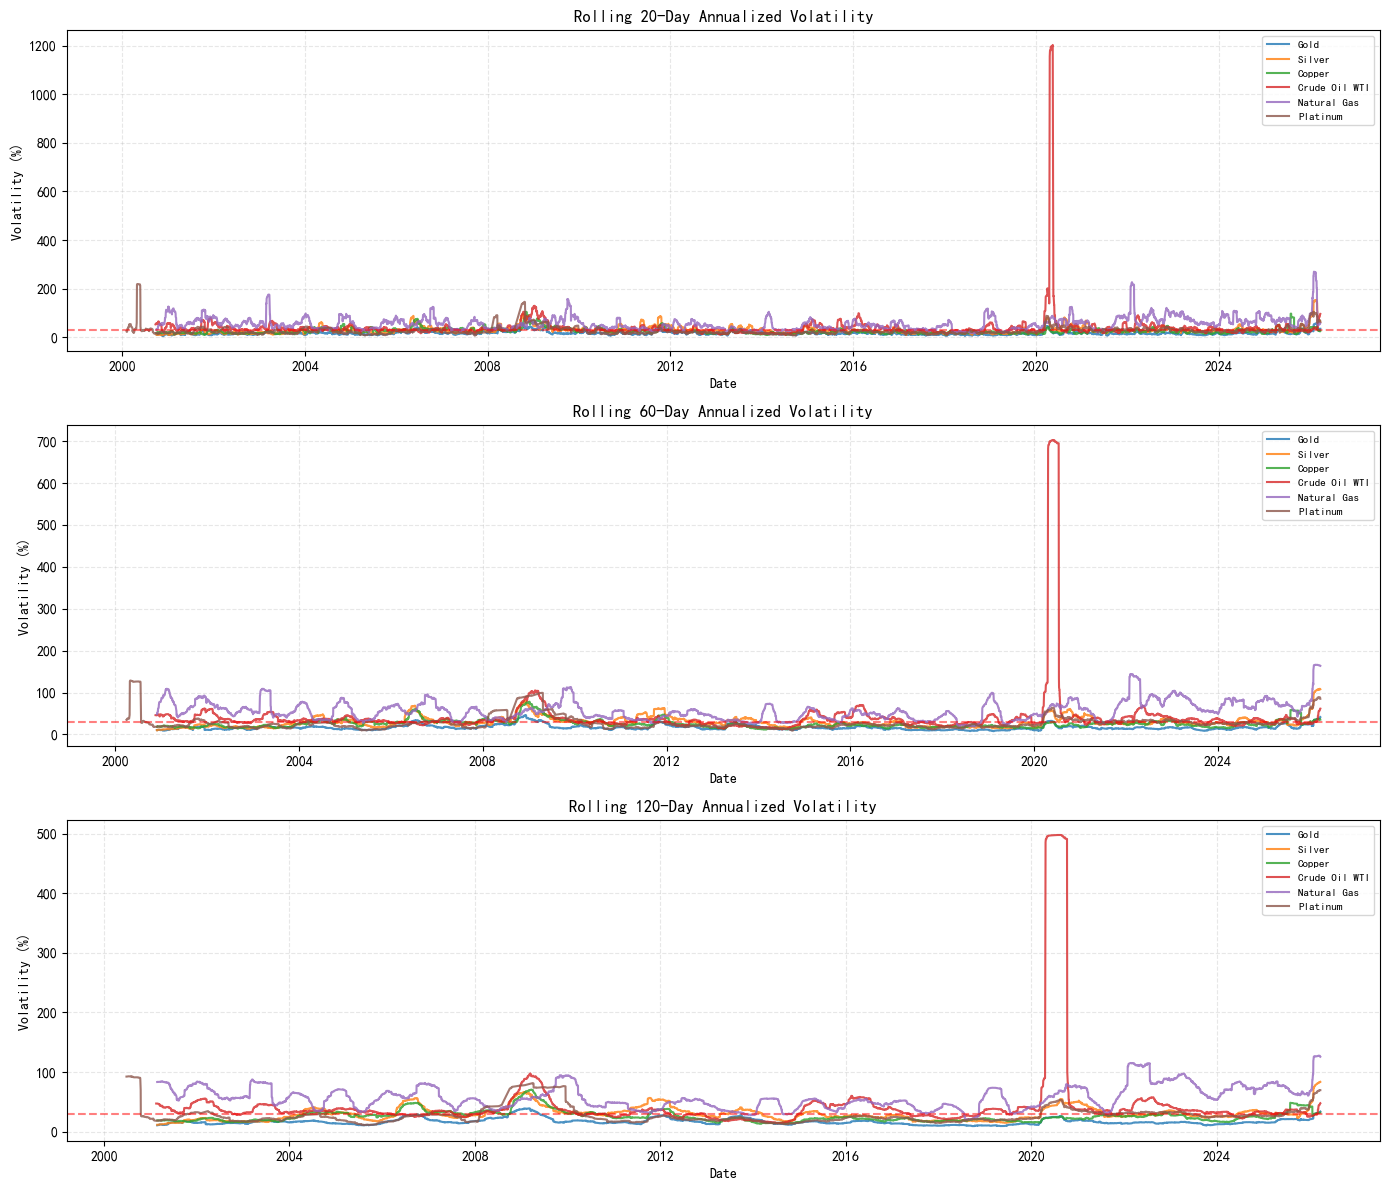



不同窗口期的平均波动率：
                  20天     60天    120天
Gold           16.30%  16.60%  16.73%
Silver         29.12%  29.69%  29.87%
Copper         24.84%  25.36%  25.62%
Crude Oil WTI  38.71%  41.52%  44.24%
Natural Gas    55.34%  56.64%  57.16%
Platinum       25.81%  26.59%  26.48%


In [55]:

# 设置滚动窗口
windows = [20, 60, 120]  # 20天=1月, 60天=1季度, 120天=半年

# 创建波动率图
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for idx, window in enumerate(windows):
    ax = axes[idx]
    
    for commodity in commodities:
        # 计算滚动波动率（年化）
        rolling_vol = returns_dict[commodity].rolling(window=window).std() * np.sqrt(252) * 100
        ax.plot(rolling_vol.index, rolling_vol.values, label=commodity, linewidth=1.5, alpha=0.8)
    
    ax.set_title(f'Rolling {window}-Day Annualized Volatility', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Volatility (%)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3, linestyle='--')
    ax.axhline(y=30, color='red', linestyle='--', alpha=0.5, label='High Vol Threshold')

plt.tight_layout()
plt.show()

# 计算波动率统计
print("\n\n不同窗口期的平均波动率：")

vol_comparison = pd.DataFrame()
for window in windows:
    for commodity in commodities:
        rolling_vol = returns_dict[commodity].rolling(window=window).std() * np.sqrt(252) * 100
        vol_comparison.loc[commodity, f'{window}天'] = f"{rolling_vol.mean():.2f}%"

print(vol_comparison)


#####  极端价格变动分析

主要识别价格变动超过3倍标准差的极端事件，分析其发生的频率和影响。绘制极端事件的时间分布图，观察是否存在集中发生的时期。标注极端事件发生的日期和对应的价格变动幅度，可以用来分析其可能的原因（如经济危机、自然灾害等）。


各商品极端收益事件统计（超过3个标准差）：

Gold:
  极端上涨事件: 36 次 (0.56%)
  极端下跌事件: 51 次 (0.80%)
  最大单日上涨: 9.03%
  最大单日下跌: -11.37%

Silver:
  极端上涨事件: 41 次 (0.64%)
  极端下跌事件: 58 次 (0.90%)
  最大单日上涨: 14.03%
  最大单日下跌: -31.35%

Copper:
  极端上涨事件: 43 次 (0.67%)
  极端下跌事件: 52 次 (0.81%)
  最大单日上涨: 13.25%
  最大单日下跌: -22.25%

Crude Oil WTI:
  极端上涨事件: 10 次 (0.16%)
  极端下跌事件: 6 次 (0.09%)
  最大单日上涨: 37.66%
  最大单日下跌: -305.97%

Natural Gas:
  极端上涨事件: 52 次 (0.81%)
  极端下跌事件: 25 次 (0.39%)
  最大单日上涨: 46.48%
  最大单日下跌: -47.48%

Platinum:
  极端上涨事件: 28 次 (0.47%)
  极端下跌事件: 25 次 (0.42%)
  最大单日上涨: 37.10%
  最大单日下跌: -43.47%


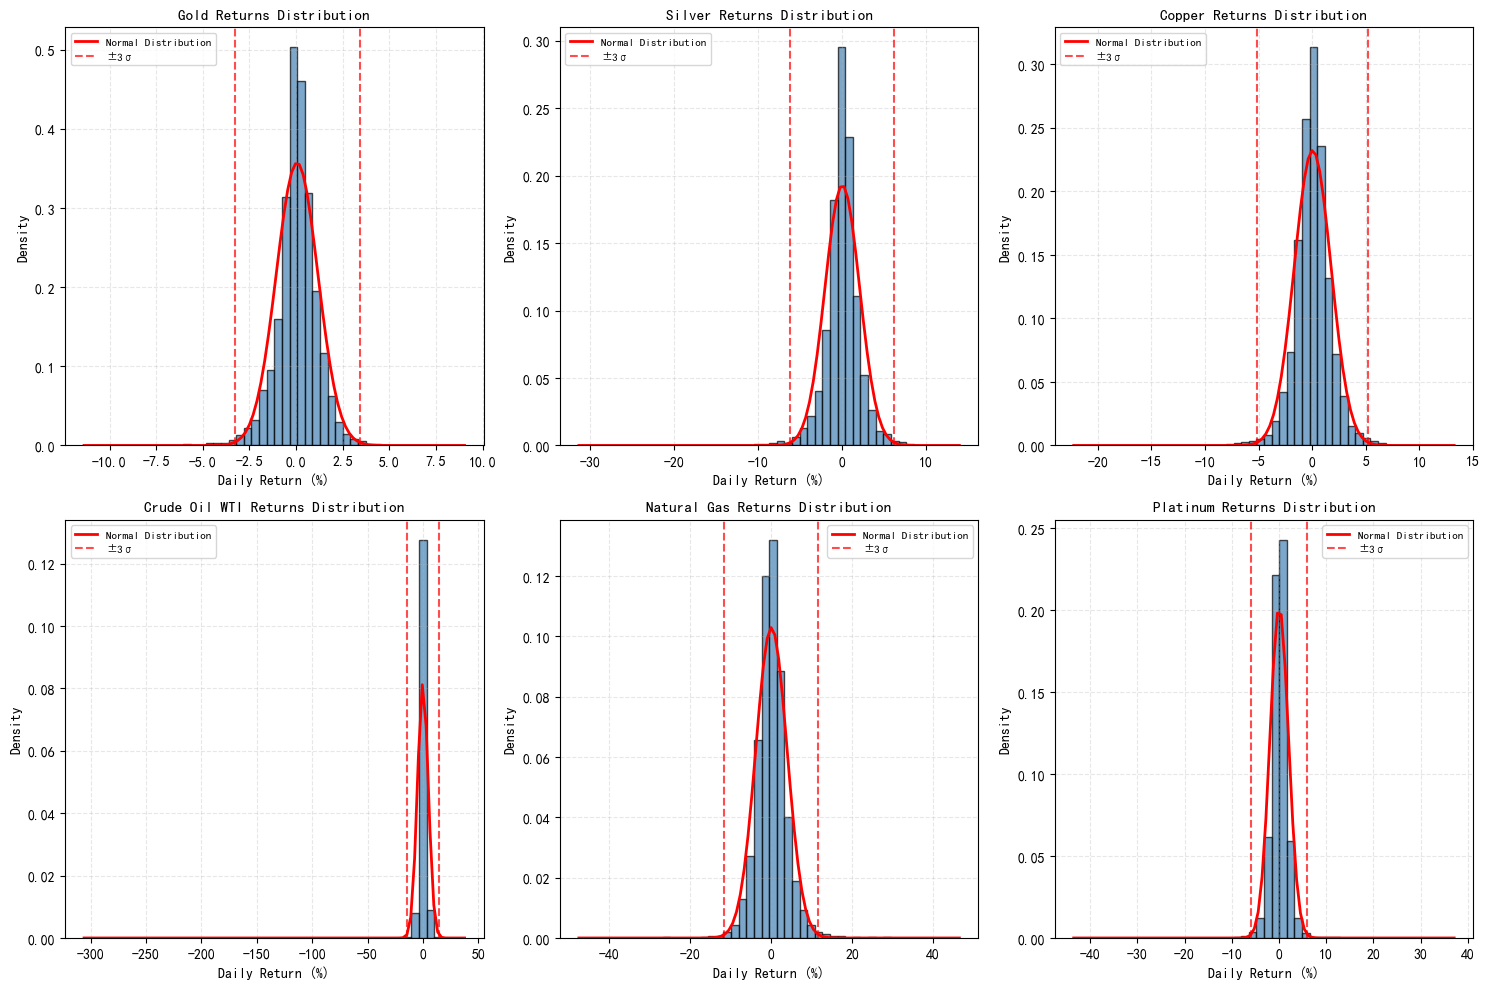



各商品收益分布特征：
                    偏度        峰度     JB检验p值 正态分布
Gold            -0.340     6.511  5.40e-213    否
Silver          -0.957    13.625   0.00e+00    否
Copper          -0.309     8.416  9.58e-243    否
Crude Oil WTI  -40.867  2467.516   0.00e+00    否
Natural Gas      0.651    12.786   0.00e+00    否
Platinum        -1.770    93.360   0.00e+00    否


In [56]:
# 识别极端收益事件
extreme_threshold = 3  # 3个标准差

extreme_events_summary = {}

print("\n各商品极端收益事件统计（超过3个标准差）：")

for commodity in commodities:
    returns = returns_dict[commodity]
    mean = returns.mean()
    std = returns.std()
    
    # 识别极端上涨和下跌
    extreme_up = returns > mean + extreme_threshold * std
    extreme_down = returns < mean - extreme_threshold * std
    
    extreme_up_count = extreme_up.sum()
    extreme_down_count = extreme_down.sum()
    total_days = len(returns)
    
    extreme_events_summary[commodity] = {
        'Extreme_Up': extreme_up_count,
        'Extreme_Down': extreme_down_count,
        'Total_Extreme': extreme_up_count + extreme_down_count
    }
    
    print(f"\n{commodity}:")
    print(f"  极端上涨事件: {extreme_up_count} 次 ({extreme_up_count/total_days*100:.2f}%)")
    print(f"  极端下跌事件: {extreme_down_count} 次 ({extreme_down_count/total_days*100:.2f}%)")
    
    if extreme_up_count > 0:
        print(f"  最大单日上涨: {returns[extreme_up].max()*100:.2f}%")
    if extreme_down_count > 0:
        print(f"  最大单日下跌: {returns[extreme_down].min()*100:.2f}%")

# 绘制极端事件分布图
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, commodity in enumerate(commodities):
    ax = axes[idx]
    returns = returns_dict[commodity] * 100  # 转换为百分比
    
    # 绘制直方图
    ax.hist(returns, bins=50, alpha=0.7, color='steelblue', edgecolor='black', density=True)
    
    # 添加正态分布曲线
    x = np.linspace(returns.min(), returns.max(), 100)
    ax.plot(x, stats.norm.pdf(x, returns.mean(), returns.std()), 
            'r-', linewidth=2, label='Normal Distribution')
    
    # 标记极端区域
    ax.axvline(x=returns.mean() + 3*returns.std(), color='red', linestyle='--', 
               alpha=0.7, label='±3σ')
    ax.axvline(x=returns.mean() - 3*returns.std(), color='red', linestyle='--', 
               alpha=0.7)
    
    ax.set_title(f'{commodity} Returns Distribution', fontsize=11, fontweight='bold')
    ax.set_xlabel('Daily Return (%)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n\n各商品收益分布特征：")

distribution_stats = pd.DataFrame()
for commodity in commodities:
    returns = returns_dict[commodity]
    
    # 正态性检验
    stat, p_value = stats.normaltest(returns)
    is_normal = "是" if p_value > 0.05 else "否"
    
    distribution_stats.loc[commodity, '偏度'] = f"{returns.skew():.3f}"
    distribution_stats.loc[commodity, '峰度'] = f"{returns.kurtosis():.3f}"
    distribution_stats.loc[commodity, 'JB检验p值'] = f"{p_value:.2e}"
    distribution_stats.loc[commodity, '正态分布'] = is_normal

print(distribution_stats)


##### 小结

In [57]:
print("波动性与风险分析总结")

print("\n【各商品风险特征】")

# 找出各指标最优的商品
best_sharpe = commodities[np.argmax([
    ((returns_dict[c].mean() * 252 - 0.02) / (returns_dict[c].std() * np.sqrt(252)))
    for c in commodities
])]

best_vol = commodities[np.argmin([
    returns_dict[c].std() * np.sqrt(252)
    for c in commodities
])]

best_var = commodities[np.argmin([
    np.percentile(returns_dict[c], 5)
    for c in commodities
])]

print(f"1. 最高夏普比率: {best_sharpe} (风险调整后收益最佳)")
print(f"2. 最低波动率: {best_vol} (价格最稳定)")
print(f"3. 最低VaR (95%): {best_var} (极端损失风险最小)")

print("\n【分析】")

recommendations = {
    'Gold': '避险资产，波动率相对较低，适合风险厌恶型投资者',
    'Silver': '波动率高于黄金，兼具避险和工业属性',
    'Copper': '高波动率，与经济周期高度相关，适合趋势跟踪',
    'Crude Oil WTI': '高波动率，受地缘政治影响大，风险较高',
    'Natural Gas': '最高波动率，季节性明显，适合专业投资者',
    'Platinum': '波动率适中，与黄金相关性强'
}

for commodity in commodities:
    print(f"\n{commodity}:")
    print(f"  {recommendations[commodity]}")

print("\n【风险提示】")
print("   建议分散投资，降低单一商品风险")
print("   高波动商品适合定投或分批建仓策略")



波动性与风险分析总结

【各商品风险特征】
1. 最高夏普比率: Gold (风险调整后收益最佳)
2. 最低波动率: Gold (价格最稳定)
3. 最低VaR (95%): Natural Gas (极端损失风险最小)

【分析】

Gold:
  避险资产，波动率相对较低，适合风险厌恶型投资者

Silver:
  波动率高于黄金，兼具避险和工业属性

Copper:
  高波动率，与经济周期高度相关，适合趋势跟踪

Crude Oil WTI:
  高波动率，受地缘政治影响大，风险较高

Natural Gas:
  最高波动率，季节性明显，适合专业投资者

Platinum:
  波动率适中，与黄金相关性强

【风险提示】
   建议分散投资，降低单一商品风险
   高波动商品适合定投或分批建仓策略


#### 预测与建模

In [58]:
# - 数据准备
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("预测与建模")

# 选择预测目标：黄金（最具有代表性）
target_commodity = 'Gold'
print(f"\n预测目标：{target_commodity} 价格")

# 准备数据
commodity_data = data[data['Commodity'] == target_commodity].copy()
commodity_data = commodity_data.sort_values('Date').reset_index(drop=True)

# 创建特征
def create_features(df):
    # 创建时间序列特征
    df = df.copy()
    
    # 滞后特征
    for lag in [1, 2, 3, 5, 7, 14, 21, 30]:
        df[f'lag_{lag}'] = df['Close'].shift(lag)
    
    # 移动平均
    for window in [5, 10, 20, 50]:
        df[f'ma_{window}'] = df['Close'].rolling(window=window).mean()
        df[f'ma_{window}_std'] = df['Close'].rolling(window=window).std()
    
    # 价格变化率
    for period in [1, 5, 10, 20]:
        df[f'return_{period}'] = df['Close'].pct_change(period)
    
    # 动量指标
    df['momentum_5'] = df['Close'] / df['Close'].shift(5) - 1
    df['momentum_20'] = df['Close'] / df['Close'].shift(20) - 1
    
    # RSI（相对强弱指标）
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['rsi'] = 100 - (100 / (1 + rs))
    
    # 日期特征
    df['year'] = df['Date'].dt.year
    df['month'] = df['Date'].dt.month
    df['day'] = df['Date'].dt.day
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['quarter'] = df['Date'].dt.quarter
    
    return df


commodity_data = create_features(commodity_data)

# 删除NaN值
commodity_data = commodity_data.dropna()

# 划分特征和目标变量
feature_cols = [col for col in commodity_data.columns 
                if col not in ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 
                               'Ticker', 'Commodity', 'Year', 'YearMonth', 
                               'Period', 'Returns']]

X = commodity_data[feature_cols]
y = commodity_data['Close']

# 划分训练集和测试集（80% 训练，20% 测试）
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 日期索引
train_dates = commodity_data['Date'][:train_size]
test_dates = commodity_data['Date'][train_size:]

print(f"\n数据集大小：")
print(f"  训练集: {len(X_train)} 样本")
print(f"  测试集: {len(X_test)} 样本")
print(f"  特征数量: {len(feature_cols)}")

# 标准化特征
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n特征列表：")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")


预测与建模

预测目标：Gold 价格

数据集大小：
  训练集: 5092 样本
  测试集: 1274 样本
  特征数量: 31

特征列表：
   1. Month
   2. Quarter
   3. DayOfWeek
   4. lag_1
   5. lag_2
   6. lag_3
   7. lag_5
   8. lag_7
   9. lag_14
  10. lag_21
  11. lag_30
  12. ma_5
  13. ma_5_std
  14. ma_10
  15. ma_10_std
  16. ma_20
  17. ma_20_std
  18. ma_50
  19. ma_50_std
  20. return_1
  21. return_5
  22. return_10
  23. return_20
  24. momentum_5
  25. momentum_20
  26. rsi
  27. year
  28. month
  29. day
  30. dayofweek
  31. quarter


##### 线性回归模型

线性回归模型


线性回归模型性能对比：
模型名称                            训练RMSE       测试RMSE        测试MAE       测试R²
Linear Regression                 4.54        21.79        10.48     0.9993
Ridge Regression                  5.55        27.70        13.95     0.9989
Lasso Regression                  5.43        28.96        14.10     0.9989

最佳线性模型: Linear Regression
  测试集 R²: 0.9993
  测试集 RMSE: 21.79


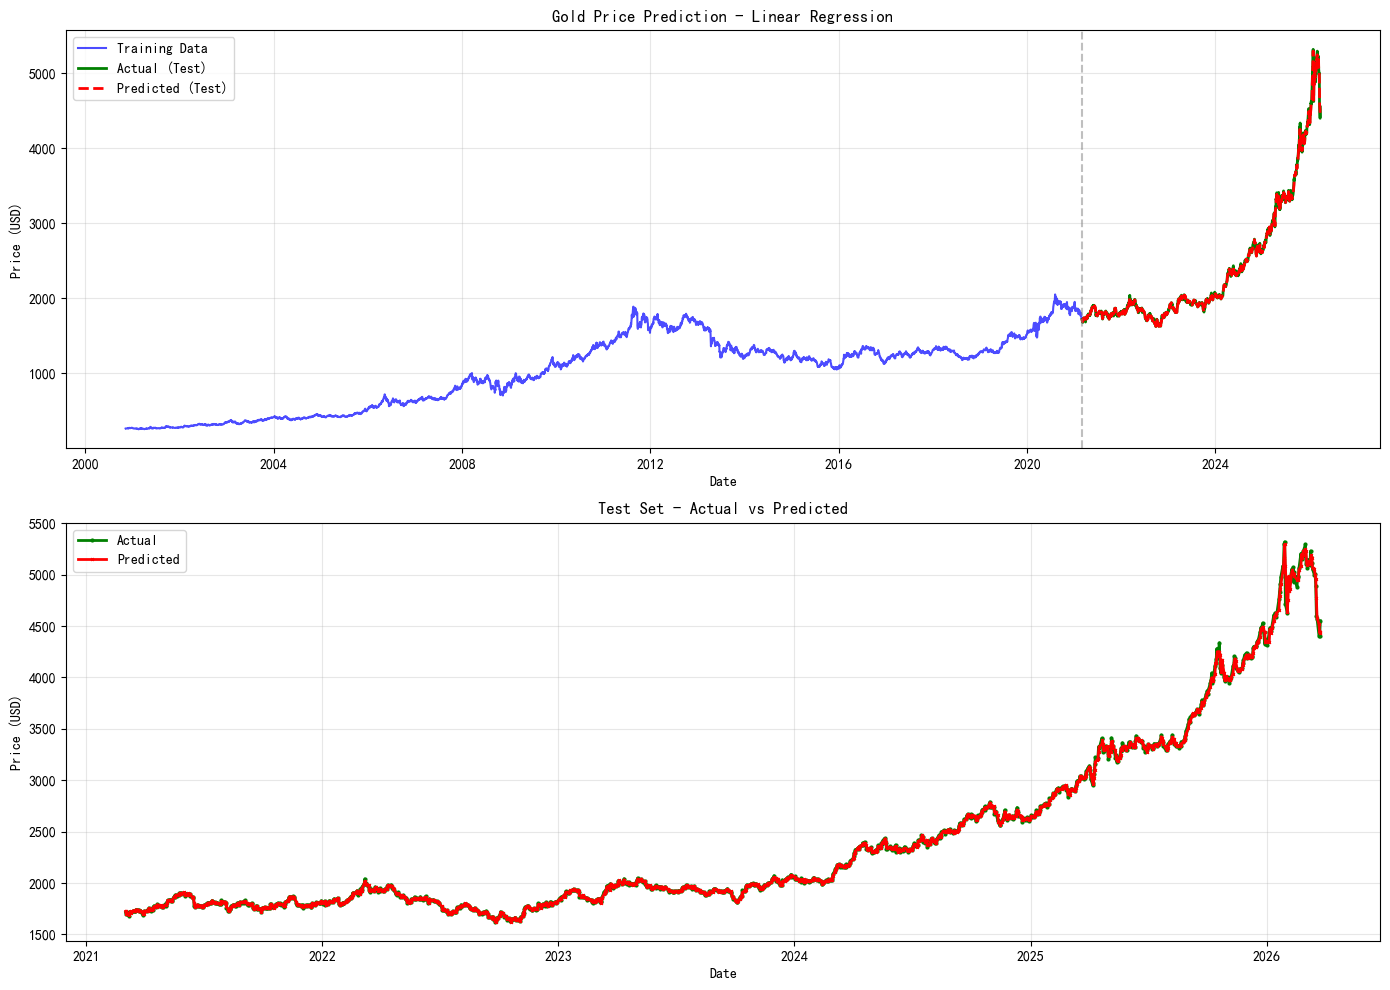

In [59]:
# 线性回归模型
print("线性回归模型\n")

# 训练多个线性模型
linear_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0)
}
# 线性回归、岭回归（L2正则化）和套索回归（L1正则化）

linear_results = {}

for name, model in linear_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    # 计算指标
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    linear_results[name] = {
        'model': model,
        'train_pred': y_pred_train,
        'test_pred': y_pred_test,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_r2': train_r2,
        'test_r2': test_r2
    }

# 显示结果
print("\n线性回归模型性能对比：")
print(f"{'模型名称':<25} {'训练RMSE':>12} {'测试RMSE':>12} {'测试MAE':>12} {'测试R²':>10}")

for name, results in linear_results.items():
    print(f"{name:<25} {results['train_rmse']:>12.2f} {results['test_rmse']:>12.2f} "
          f"{results['test_mae']:>12.2f} {results['test_r2']:>10.4f}")

# 可视化  选择最佳线性模型
best_linear_name = max(linear_results.keys(), 
                      key=lambda x: linear_results[x]['test_r2'])
best_linear = linear_results[best_linear_name]

print(f"\n最佳线性模型: {best_linear_name}")
print(f"  测试集 R²: {best_linear['test_r2']:.4f}")
print(f"  测试集 RMSE: {best_linear['test_rmse']:.2f}")

# 绘制预测结果
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 完整时间序列
ax = axes[0]
ax.plot(train_dates, y_train, label='Training Data', color='blue', alpha=0.7)
ax.plot(test_dates, y_test, label='Actual (Test)', color='green', linewidth=2)
ax.plot(test_dates, best_linear['test_pred'], label='Predicted (Test)', 
        color='red', linestyle='--', linewidth=2)
ax.axvline(x=train_dates.iloc[-1], color='gray', linestyle='--', alpha=0.5)
ax.set_title(f'{target_commodity} Price Prediction - {best_linear_name}', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left') # 图例放在左上角
ax.grid(alpha=0.3)

# 测试集放大，更清晰地比较实际值和预测值
ax = axes[1]
ax.plot(test_dates, y_test, label='Actual', color='green', linewidth=2, marker='o', markersize=2)
# 预测值用红色实线和标记显示，便于区分。marker='x' 表示用叉号标记预测点，markersize=2 设置标记大小。
ax.plot(test_dates, best_linear['test_pred'], label='Predicted', 
        color='red', linewidth=2, marker='x', markersize=2)
ax.fill_between(test_dates, y_test, best_linear['test_pred'], alpha=0.3, color='gray')
ax.set_title('Test Set - Actual vs Predicted', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


##### 集成学习模型

直接列出特征重要性排名，能够看出哪些商品价格对预测目标影响最大。


训练 Random Forest...
  训练集 R²: 1.0000
  测试集 R²: -0.2424

训练 Gradient Boosting...
  训练集 R²: 1.0000
  测试集 R²: -0.2374

集成学习模型性能对比：
模型名称                            训练RMSE       测试RMSE        测试MAE       测试R²
Random Forest                     2.82       951.93       516.18    -0.2424
Gradient Boosting                 1.90       950.04       511.21    -0.2374


特征重要性 TOP 10 (Random Forest)：
 1. lag_1                : 0.8361
 2. ma_5                 : 0.1442
 3. lag_2                : 0.0060
 4. ma_50                : 0.0048
 5. ma_10                : 0.0031
 6. ma_20                : 0.0029
 7. lag_3                : 0.0012
 8. lag_30               : 0.0010
 9. return_1             : 0.0004
10. lag_21               : 0.0002


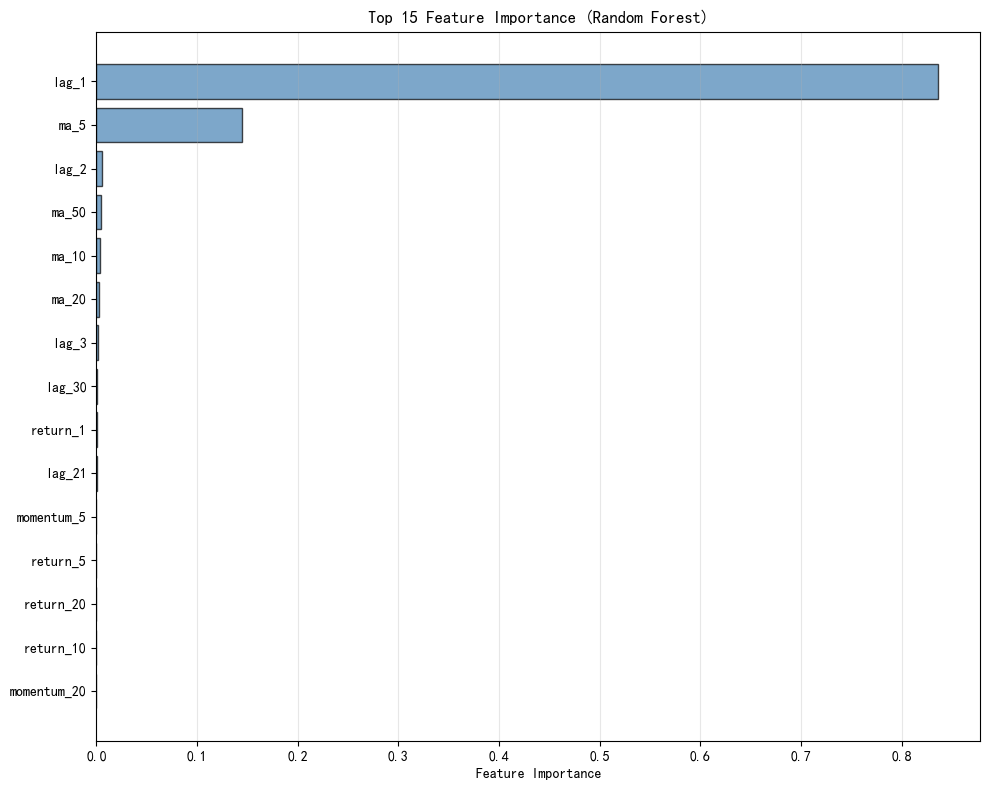

In [60]:
# 集成学习模型，就是通过组合多个模型的预测结果来提高整体性能的方法。

# 训练集成模型
ensemble_models_dict = {
    'Random Forest': RandomForestRegressor(
        n_estimators=100, 
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ), # n_jobs=-1 表示使用所有可用的CPU核心进行训练，提升训练速度
    # n_estimators: 决策树的数量，越多通常性能越好，但训练时间也会增加。100为常见的默认值。
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    )
}

ensemble_results = {}

for name, model in ensemble_models_dict.items():
    print(f"\n训练 {name}...")
    
    model.fit(X_train_scaled, y_train)
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    # 计算指标
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    ensemble_results[name] = {
        'model': model,
        'train_pred': y_pred_train,
        'test_pred': y_pred_test,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_r2': train_r2,
        'test_r2': test_r2
    }
    
    print(f"  训练集 R²: {train_r2:.4f}")
    print(f"  测试集 R²: {test_r2:.4f}")

# 显示结果
print("\n集成学习模型性能对比：")
print(f"{'模型名称':<25} {'训练RMSE':>12} {'测试RMSE':>12} {'测试MAE':>12} {'测试R²':>10}")

for name, results in ensemble_results.items():
    print(f"{name:<25} {results['train_rmse']:>12.2f} {results['test_rmse']:>12.2f} "
          f"{results['test_mae']:>12.2f} {results['test_r2']:>10.4f}")

# 特征重要性（Random Forest）
rf_model = ensemble_results['Random Forest']['model']
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n\n特征重要性 TOP 10 (Random Forest)：")
for i, (_, row) in enumerate(feature_importance.head(10).iterrows(), 1):
    print(f"{i:2d}. {row['feature']:<20} : {row['importance']:.4f}")

# 可视化特征重要性
fig, ax = plt.subplots(figsize=(10, 8))

top_features = feature_importance.head(15)
ax.barh(range(len(top_features)), top_features['importance'].values, 
        color='steelblue', alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.invert_yaxis()  # 最重要的在顶部
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Feature Importance (Random Forest)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


##### 模型性能综合对比

模型性能综合对比


所有模型性能对比：
                   Train RMSE  Test RMSE  Test MAE  Train R²  Test R²
Linear Regression      4.5398    21.7852   10.4789    0.9999   0.9993
Ridge Regression       5.5536    27.7046   13.9491    0.9999   0.9989
Lasso Regression       5.4316    28.9600   14.1014    0.9999   0.9989
Random Forest          2.8211   951.9311  516.1763    1.0000  -0.2424
Gradient Boosting      1.9042   950.0420  511.2093    1.0000  -0.2374


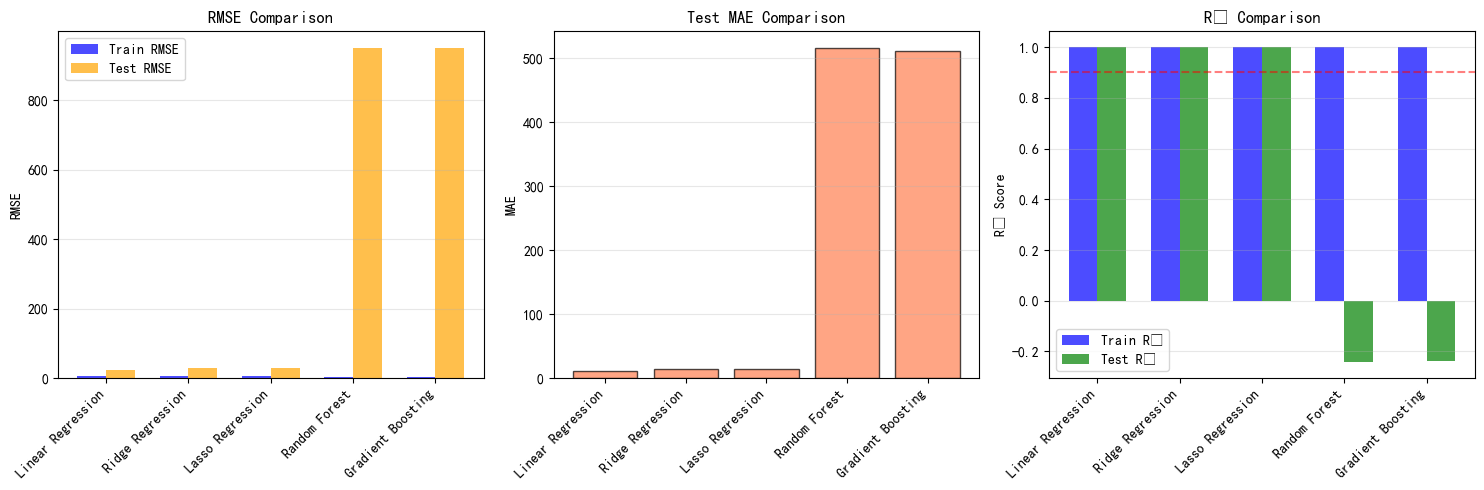

最佳模型: Linear Regression
  测试集 R²: 0.9993
  测试集 RMSE: 21.79
  测试集 MAE: 10.48
  模型评价: 优秀 - 模型解释了绝大部分价格变动


In [61]:
# 模型性能综合对比
print("模型性能综合对比\n")

# 合并所有结果
all_results = {**linear_results, **ensemble_results}

# 创建对比表
comparison_df = pd.DataFrame({
    name: {
        'Train RMSE': results['train_rmse'],
        'Test RMSE': results['test_rmse'],
        'Test MAE': results['test_mae'],
        'Train R²': results['train_r2'],
        'Test R²': results['test_r2']
    }
    for name, results in all_results.items()
}).T

print("\n所有模型性能对比：")
print(comparison_df.round(4))

# 可视化对比
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# RMSE对比
ax = axes[0]
models = list(all_results.keys())
train_rmse = [all_results[m]['train_rmse'] for m in models]
test_rmse = [all_results[m]['test_rmse'] for m in models]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, train_rmse, width, label='Train RMSE', color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, test_rmse, width, label='Test RMSE', color='orange', alpha=0.7)

ax.set_ylabel('RMSE')
ax.set_title('RMSE Comparison', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend()
ax.grid(alpha=0.3, axis='y')

# MAE对比
ax = axes[1]
test_mae = [all_results[m]['test_mae'] for m in models]

bars = ax.bar(models, test_mae, color='coral', alpha=0.7, edgecolor='black')
ax.set_ylabel('MAE')
ax.set_title('Test MAE Comparison', fontweight='bold')
ax.set_xticklabels(models, rotation=45, ha='right')
ax.grid(alpha=0.3, axis='y')

# R²对比
ax = axes[2]
train_r2 = [all_results[m]['train_r2'] for m in models]
test_r2 = [all_results[m]['test_r2'] for m in models]

bars1 = ax.bar(x - width/2, train_r2, width, label='Train R²', color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, test_r2, width, label='Test R²', color='green', alpha=0.7)

ax.set_ylabel('R² Score')
ax.set_title('R² Comparison', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend()
ax.grid(alpha=0.3, axis='y')
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='Good fit threshold')

plt.tight_layout()
plt.show()

# 找出最佳模型
best_model_name = max(all_results.keys(), key=lambda x: all_results[x]['test_r2'])
best_model = all_results[best_model_name]

print(f"最佳模型: {best_model_name}")
print(f"  测试集 R²: {best_model['test_r2']:.4f}")
print(f"  测试集 RMSE: {best_model['test_rmse']:.2f}")
print(f"  测试集 MAE: {best_model['test_mae']:.2f}")

if best_model['test_r2'] > 0.95:
    quality = "优秀 - 模型解释了绝大部分价格变动"
elif best_model['test_r2'] > 0.9:
    quality = "良好 - 模型具有较强的预测能力"
elif best_model['test_r2'] > 0.8:
    quality = "中等 - 模型有一定预测能力"
else:
    quality = "较弱 - 需要改进模型或增加特征"

print(f"  模型评价: {quality}")


##### 预测建模总结

In [62]:
# 预测建模总结
print("预测建模总结\n")

print("\n【模型性能总结】")

# 找出各指标最佳模型
best_rmse_model = min(all_results.keys(), key=lambda x: all_results[x]['test_rmse'])
best_mae_model = min(all_results.keys(), key=lambda x: all_results[x]['test_mae'])
best_r2_model = max(all_results.keys(), key=lambda x: all_results[x]['test_r2'])

print(f"1. 最佳RMSE模型: {best_rmse_model}")
print(f"   RMSE: {all_results[best_rmse_model]['test_rmse']:.2f}")

print(f"\n2. 最佳MAE模型: {best_mae_model}")
print(f"   MAE: {all_results[best_mae_model]['test_mae']:.2f}")

print(f"\n3. 最佳R²模型: {best_r2_model}")
print(f"   R²: {all_results[best_r2_model]['test_r2']:.4f}")

print("\n\n【重要特征分析】")
print("影响价格的最重要因素（Random Forest）：")

for i, row in enumerate(feature_importance.head(5).itertuples(index=False), 1):
    importance_pct = row.importance * 100
    print(f"{i}. {row.feature:<20} - 重要性: {importance_pct:.2f}%")


预测建模总结


【模型性能总结】
1. 最佳RMSE模型: Linear Regression
   RMSE: 21.79

2. 最佳MAE模型: Linear Regression
   MAE: 10.48

3. 最佳R²模型: Linear Regression
   R²: 0.9993


【重要特征分析】
影响价格的最重要因素（Random Forest）：
1. lag_1                - 重要性: 83.61%
2. ma_5                 - 重要性: 14.42%
3. lag_2                - 重要性: 0.60%
4. ma_50                - 重要性: 0.48%
5. ma_10                - 重要性: 0.31%
